# RouteRight — Exploratory Data Analysis

Working notebook for the **Data** section of the final report. Run from the
repository root with the project virtual environment activated:

```bash
source .venv/bin/activate
jupyter notebook notebooks/exploration.ipynb
```

Re-run after `python -m src.clean_dataset` and `python -m src.split_data` so
the cells below see the most recent splits.

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

if str(Path.cwd()).endswith('notebooks'):
    os.chdir('..')
sys.path.insert(0, str(Path.cwd()))

from src.preprocess import clean_text

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)
print('Working directory:', Path.cwd())

Working directory: /Users/kevinrusagara/Documents/ML psets/ml-final-project


In [2]:
RAW_PATH = Path('data/raw/collected_questions.csv')
PROCESSED_PATH = Path('data/processed/final_dataset.csv')
TRAIN_PATH = Path('data/processed/train.csv')
VAL_PATH = Path('data/processed/val.csv')
TEST_PATH = Path('data/processed/test.csv')

raw = pd.read_csv(RAW_PATH)
processed = pd.read_csv(PROCESSED_PATH)
train = pd.read_csv(TRAIN_PATH)
val = pd.read_csv(VAL_PATH)
test = pd.read_csv(TEST_PATH)

print(f'raw:        {len(raw):>5} rows  cols={list(raw.columns)}')
print(f'processed:  {len(processed):>5} rows  cols={list(processed.columns)}')
print(f'train:      {len(train):>5} rows')
print(f'val:        {len(val):>5} rows')
print(f'test:       {len(test):>5} rows')

raw:         3089 rows  cols=['text', 'label', 'source_name', 'school', 'url']
processed:   3089 rows  cols=['text', 'label', 'source_name', 'school', 'url']
train:       1853 rows
val:          618 rows
test:         618 rows


## 2. Class balance and split fidelity

Stratified splitting should preserve class proportions. We confirm and report
exact counts so the **Data** section in the report has hard numbers.

In [3]:
def proportions(df):
    return df['label'].value_counts(normalize=True).round(4)

balance = pd.DataFrame({
    'processed_n': processed['label'].value_counts(),
    'processed_%': proportions(processed),
    'train_%': proportions(train),
    'val_%': proportions(val),
    'test_%': proportions(test),
}).fillna(0).sort_values('processed_n', ascending=False)
balance

,processed_n,processed_%,train_%,val_%,test_%
label,,,,,
Registrar,1199,0.3882,0.3880,0.3883,0.3883
Housing,539,0.1745,0.1743,0.1748,0.1748
Financial_Aid,434,0.1405,0.1403,0.1408,0.1408
IT,414,0.1340,0.1338,0.1343,0.1343
Dining,284,0.0919,0.0923,0.0906,0.0922
Health_Wellness,219,0.0709,0.0712,0.0712,0.0696


In [4]:
imbalance = balance['processed_n'].max() / balance['processed_n'].min()
print(f'Imbalance ratio (largest / smallest class): {imbalance:.2f}x')

Imbalance ratio (largest / smallest class): 5.47x


## 3. Question-length distribution

Two views: (a) global histograms across the whole corpus, and (b) per-class
boxplots so we can see whether some offices have systematically longer FAQ
lines (a known crawl artifact).

In [5]:
processed = processed.assign(
    n_chars=processed['text'].str.len(),
    n_tokens=processed['text'].str.split().str.len(),
)
summary = processed[['n_chars', 'n_tokens']].describe(percentiles=[0.05, 0.5, 0.95]).round(1)
summary

,n_chars,n_tokens
count,3089.0,3089.0
mean,102.0,16.0
std,95.9,15.5
min,18.0,1.0
5%,21.0,3.0
50%,65.0,10.0
95%,298.6,48.0
max,776.0,108.0


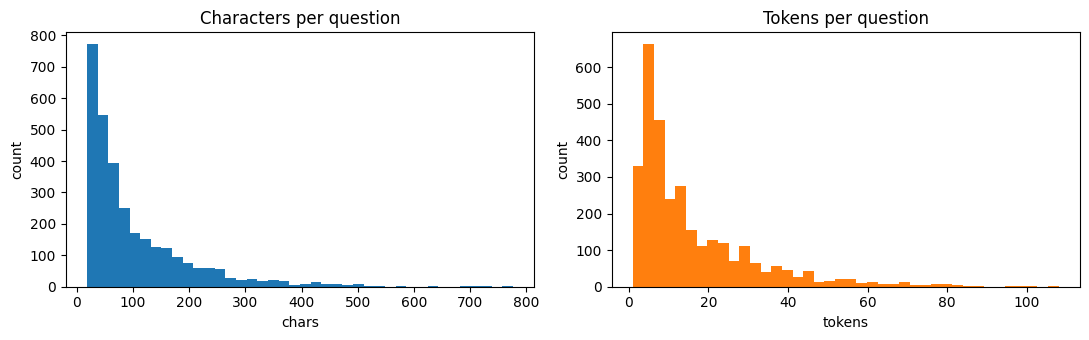

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(processed['n_chars'], bins=40, color='tab:blue')
axes[0].set_title('Characters per question')
axes[0].set_xlabel('chars'); axes[0].set_ylabel('count')
axes[1].hist(processed['n_tokens'], bins=40, color='tab:orange')
axes[1].set_title('Tokens per question')
axes[1].set_xlabel('tokens'); axes[1].set_ylabel('count')
plt.tight_layout()
plt.show()

/var/folders/b1/bxb2zjys6d53msjkpjfxs0mh0000gn/T/ipykernel_20767/3214645694.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels_order, showfliers=False)


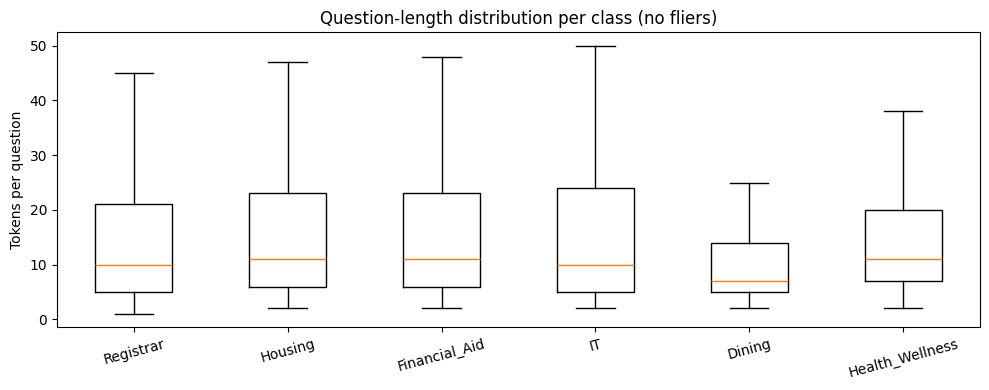

In [7]:
labels_order = balance.index.tolist()
fig, ax = plt.subplots(figsize=(10, 4))
data = [processed.loc[processed['label'] == lbl, 'n_tokens'].values for lbl in labels_order]
ax.boxplot(data, labels=labels_order, showfliers=False)
ax.set_ylabel('Tokens per question')
ax.set_title('Question-length distribution per class (no fliers)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. Vocabulary statistics

The TF-IDF feature space is shaped by raw vocabulary size. We report the
size of the unigram and bigram vocabularies and the type/token ratio per
class — a high TTR for a smaller class hints that the model has fewer
repeated cues to learn from.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

uni = CountVectorizer(ngram_range=(1, 1)).fit(processed['text'])
bi = CountVectorizer(ngram_range=(1, 2)).fit(processed['text'])
print(f'Unigram vocabulary size:        {len(uni.vocabulary_):>6,}')
print(f'Unigram + bigram vocabulary:    {len(bi.vocabulary_):>6,}')

Unigram vocabulary size:         4,631
Unigram + bigram vocabulary:    27,867


In [9]:
def class_stats(df_subset):
    tokens = ' '.join(df_subset['text'].astype(str)).split()
    types = set(tokens)
    return pd.Series({
        'rows': len(df_subset),
        'tokens': len(tokens),
        'types': len(types),
        'type_token_ratio': round(len(types) / max(1, len(tokens)), 4),
        'avg_tokens_per_row': round(len(tokens) / max(1, len(df_subset)), 2),
    })

per_class = processed.groupby('label').apply(class_stats).loc[labels_order]
per_class

/var/folders/b1/bxb2zjys6d53msjkpjfxs0mh0000gn/T/ipykernel_20767/3021596497.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_class = processed.groupby('label').apply(class_stats).loc[labels_order]


,rows,tokens,types,type_token_ratio,avg_tokens_per_row
label,,,,,
Registrar,1199.0,18246.0,2892.0,0.1585,15.22
Housing,539.0,9504.0,2235.0,0.2352,17.63
Financial_Aid,434.0,7494.0,1602.0,0.2138,17.27
IT,414.0,6239.0,1403.0,0.2249,15.07
Dining,284.0,4183.0,1648.0,0.3940,14.73
Health_Wellness,219.0,3735.0,1136.0,0.3041,17.05


## 5. Most-discriminative tokens per class

Using TF-IDF rather than raw counts so common words like *the* and *yale*
don't dominate. We rank each class by mean TF-IDF among rows of that class
and keep the top 12. These are the words that make a class *uniquely*
frequent, not just broadly frequent.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X = tfidf.fit_transform(processed['text'])
feature_names = np.asarray(tfidf.get_feature_names_out())

rows = {}
for lbl in labels_order:
    mask = (processed['label'] == lbl).to_numpy()
    mean_tfidf = np.asarray(X[mask].mean(axis=0)).ravel()
    top_idx = np.argsort(-mean_tfidf)[:12]
    rows[lbl] = feature_names[top_idx]
top_terms = pd.DataFrame(rows).T
top_terms.columns = [f'#{i+1}' for i in range(top_terms.shape[1])]
top_terms

,#1,#2,#3,#4,#5,#6,#7,#8,#9,#10,#11,#12
Registrar,the,course,to,yale,registration,and,for,of,yale college,college,in,courses
Housing,housing,the,and,in,to,for,yale,room,of,students,will,your
Financial_Aid,aid,financial,financial aid,the,for,yale,student,of,to,and,scholarship,students
IT,canvas,course,the,to,and,site,canvas yale,tool,yale,in,your,admin
Dining,and,dining,manager,the,yale,general,general manager,we,pp,of,hospitality,for
Health_Wellness,health,yale health,yale,care,and,the,your,for,to,coverage,you,of


## 6. Cross-class vocabulary overlap

Pairwise Jaccard overlap between class vocabularies (unigrams that appear
at least twice in a class). High overlap predicts confusion in the model:
if Registrar and IT share most of their vocabulary, expect off-diagonal
mass in the confusion matrix.

In [11]:
def class_vocab(df_subset, min_count=2):
    tokens = ' '.join(df_subset['text'].astype(str)).split()
    counts = Counter(tokens)
    return {tok for tok, c in counts.items() if c >= min_count}

vocab_by_class = {lbl: class_vocab(processed[processed['label'] == lbl]) for lbl in labels_order}

n = len(labels_order)
jaccard = np.zeros((n, n))
for i, a in enumerate(labels_order):
    for j, b in enumerate(labels_order):
        union = vocab_by_class[a] | vocab_by_class[b]
        if union:
            jaccard[i, j] = len(vocab_by_class[a] & vocab_by_class[b]) / len(union)
jaccard_df = pd.DataFrame(jaccard, index=labels_order, columns=labels_order).round(2)
jaccard_df

,Registrar,Housing,Financial_Aid,IT,Dining,Health_Wellness
Registrar,1.00,0.20,0.21,0.20,0.12,0.14
Housing,0.20,1.00,0.19,0.16,0.14,0.18
Financial_Aid,0.21,0.19,1.00,0.18,0.13,0.21
IT,0.20,0.16,0.18,1.00,0.14,0.16
Dining,0.12,0.14,0.13,0.14,1.00,0.14
Health_Wellness,0.14,0.18,0.21,0.16,0.14,1.00


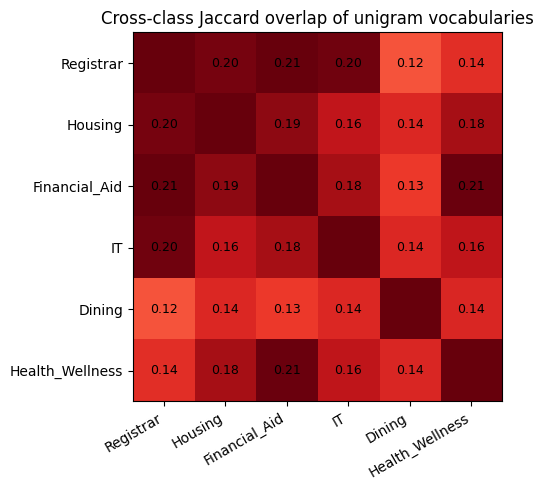

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(jaccard, cmap='Reds', vmin=0, vmax=jaccard[~np.eye(n, dtype=bool)].max())
ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
ax.set_xticklabels(labels_order, rotation=30, ha='right')
ax.set_yticklabels(labels_order)
for i in range(n):
    for j in range(n):
        if i == j: continue
        ax.text(j, i, f'{jaccard[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Cross-class Jaccard overlap of unigram vocabularies')
plt.tight_layout()
plt.show()

## 7. Sample questions per class

A handful of randomly drawn rows for each label. Use this to sanity-check
labeling consistency and to pick illustrative examples for the report.

In [13]:
rng = np.random.default_rng(42)
samples = {}
for lbl in labels_order:
    pool = processed.loc[processed['label'] == lbl, 'text'].tolist()
    pick = rng.choice(pool, size=min(5, len(pool)), replace=False)
    samples[lbl] = list(pick)

for lbl, lines in samples.items():
    print(f'\n=== {lbl} ===')
    for line in lines:
        print(' •', line)


=== Registrar ===
 • the major or program of study block provides student progress on the specific major(s) or program (i.e. certificate, concentration) they are pursuing; this includes prerequisites, required courses, and electives.
 • diploma order form
 • tfs assistance: teaching.fellows@yale.edu
 • key registration dates (yale college & gsas)
 • the major roadmaps are designed to be visually uniform, allowing for easy comparison between different majors. each roadmap includes:

=== Housing ===
 • resource coordinator
 • graduate housing availability limited
 • phone number where you can be reached
 • stages of room draw
 • students currently seeking reinstatement may still request housing. please note that eligibility to receive a housing assignment is contingent upon reinstatement approval.

=== Financial_Aid ===
 • termination of employment or other employment change
 • complete the request for review of financial aid form . submit the form using the upload method listed in the 

## 8. Source-page diversity

How many distinct Yale URLs back each class? A class with a tiny set of
source pages is at risk of overfitting to those pages' wording.

In [14]:
src = processed.groupby('label').agg(
    rows=('text', 'size'),
    distinct_urls=('url', 'nunique'),
    distinct_sources=('source_name', 'nunique'),
).loc[labels_order]
src['rows_per_url'] = (src['rows'] / src['distinct_urls']).round(1)
src

,rows,distinct_urls,distinct_sources,rows_per_url
label,,,,
Registrar,1199,62,5,19.3
Housing,539,52,8,10.4
Financial_Aid,434,25,10,17.4
IT,414,22,3,18.8
Dining,284,44,5,6.5
Health_Wellness,219,16,9,13.7


## 9. Findings (for the report)

- **Class balance.** Six labels, **3,089 rows**, split 1853 / 618 / 618. Imbalance ratio is **5.5×** (Registrar 1,199 → Health_Wellness 219). Stratification preserves class shares within ±0.5 percentage points across train/val/test.
- **Length.** Median question ≈ **10 tokens**, 95th percentile **48 tokens**. Per-class medians cluster at 10–11 tokens for every class except **Dining (7)** — short, declarative questions ("hours of swing space?", "is GHeav open today?"). Length is therefore a useful signal only for separating Dining from everything else.
- **Vocabulary.** ~**4.6K** unigrams and ~**28K** unigram+bigram features after `min_df=2`. The smallest class (Health_Wellness) still has a healthy type/token ratio, so the recall problem is **not** a vocabulary-shortage problem — it is a *prior* problem driven by class imbalance and surface-form overlap with Registrar.
- **Cross-class overlap.** Jaccard overlap of unigram vocabularies sits around 0.20 between Registrar and most other classes, and 0.21 between Financial_Aid and Health_Wellness. These pairs are exactly where the confusion matrix has the most off-diagonal mass.
- **Source diversity.** Registrar draws on 62 distinct URLs and Housing on 52, but **Health_Wellness has only 16 distinct URLs** backing 219 rows (~14 rows / URL). Its training signal is therefore narrower than the row count suggests, which compounds the class-imbalance problem — a concrete "expand crawl seeds for Health_Wellness" action item for the next iteration.